# Chain Walk Experiments
Comparing RPI vs CRPI with Linear and Polynomial Function Approximation

In [1]:
import numpy as np
from environments.chain_walk import ChainWalkEnv
from function_approximation.linear_fa import LinearFA
from function_approximation.polynomial_fa import PolynomialFA
from utils import run_experiment, run_polynomial_sweep

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [16]:
# Environment Setup
env = ChainWalkEnv(N=50, p=0.9)

# Get state/action dimensions for FA
P, R = env.get_mdp_matrices()
n_states = P.shape[0]
n_actions = P.shape[1]

# Hyperparameters
gamma = 0.9
iters = 200
n_seeds = 1

print(f"Environment: Chain Walk")
print(f"States: {n_states}, Actions: {n_actions}")
print(f"Gamma: {gamma}, Iterations: {iters}, Seeds: {n_seeds}")

Environment: Chain Walk
States: 50, Actions: 2
Gamma: 0.9, Iterations: 200, Seeds: 1


## Section 1: Linear Function Approximation

Running 1 seeds for Linear FA...


RPI: 100%|██████████| 200/200 [00:23<00:00,  8.43it/s]


198


CRPI: 100%|██████████| 200/200 [00:23<00:00,  8.37it/s]


177
Plot saved to: plots/Linear_FA/RPI_vs_CRPI_Linear_FA_20260308_170048.png


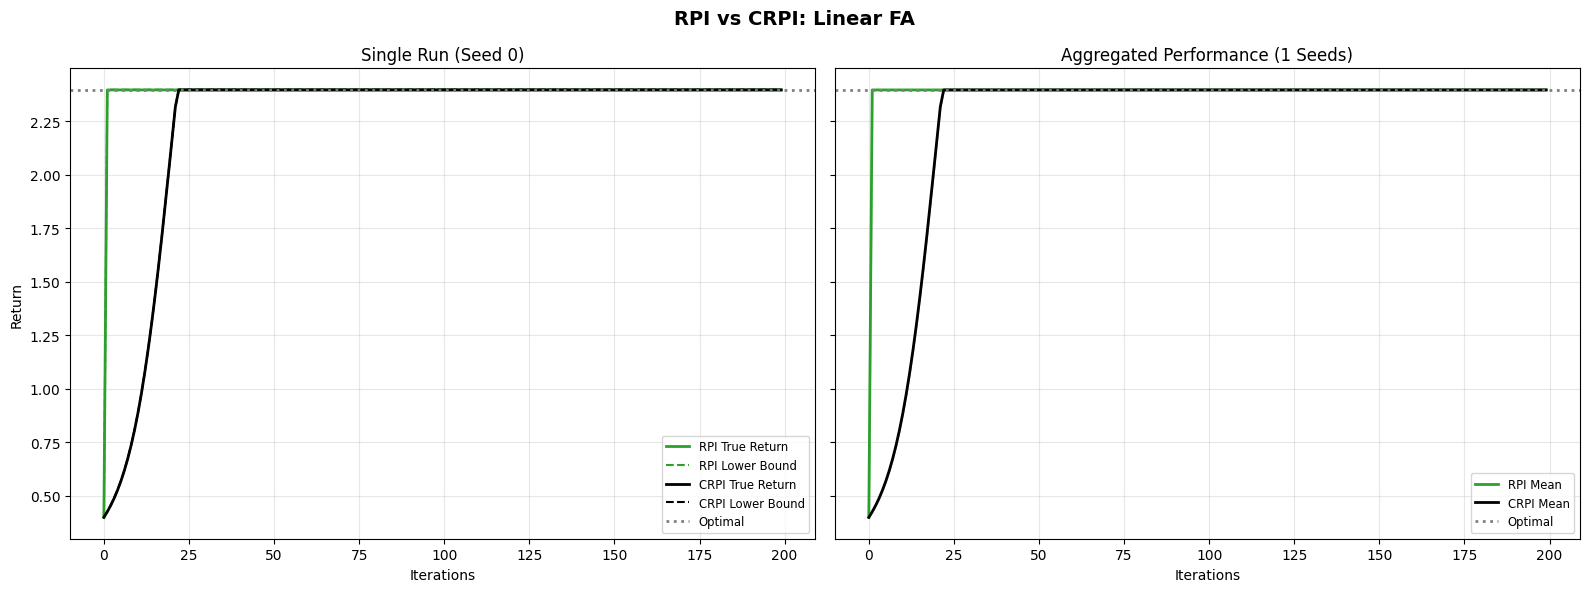

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,476.1 ± 0.0,2.40 ± 0.00
1,CRPI,449.5 ± 0.0,2.40 ± 0.00


In [17]:
# Linear FA Experiment
d_features = 100

linear_results = run_experiment(
    env=env,
    fa_class=LinearFA,
    gamma=gamma,
    iters=iters,
    n_seeds=n_seeds,
    fa_params={'n_states': n_states, 'n_actions': n_actions, 'd_features': d_features},
    title_suffix="Linear FA",
    verbose=True
)

## Section 2: Polynomial Function Approximation


POLYNOMIAL DEGREE: 1


RPI:   0%|          | 0/200 [00:00<?, ?it/s]/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
RPI: 100%|██████████| 200/200 [01:20<00:00,  2.49it/s]


0


CRPI: 100%|██████████| 200/200 [00:55<00:00,  3.59it/s]


0


RPI:   0%|          | 0/200 [00:00<?, ?it/s]/home/sans/.local/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
RPI: 100%|██████████| 200/200 [01:16<00:00,  2.61it/s]


0


CRPI: 100%|██████████| 200/200 [00:59<00:00,  3.35it/s]


2
Plot saved to: plots/polynomial_sweep/Polynomial_Degree_1_20260308_170607.png


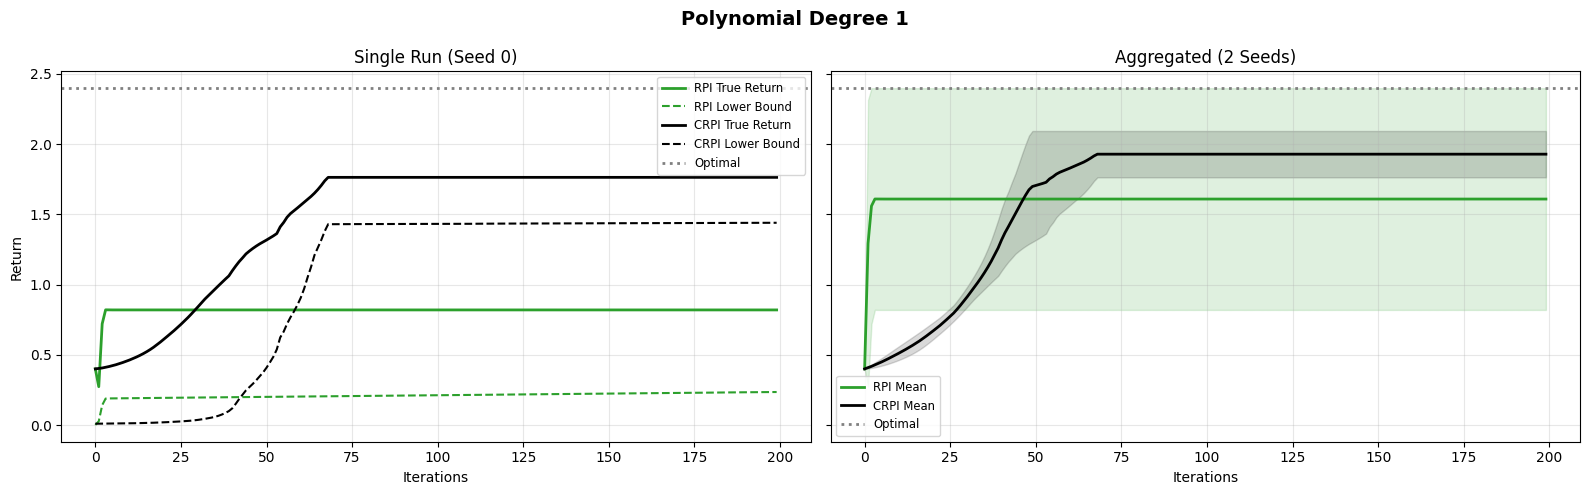

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,319.1 ± 156.9,1.61 ± 0.79
1,CRPI,329.7 ± 32.5,1.93 ± 0.16



SUMMARY ACROSS ALL DEGREES


,Degree,RPI Terminal,CRPI Terminal
0,1,1.608,1.928


In [18]:
# Polynomial FA Experiment - Sweep across degrees
degrees = [1]
poly_n_seeds = 2  # Fewer seeds for polynomial sweep (more expensive)

poly_results, poly_summary = run_polynomial_sweep(
    env=env,
    poly_fa_class=PolynomialFA,
    degrees=degrees,
    gamma=gamma,
    iters=iters,
    n_seeds=poly_n_seeds,
    base_fa_params={'n_states': n_states, 'n_actions': n_actions, 'd_features': 90},
    verbose=True
)